In [1]:
from google.colab import files
import pandas as pd
import io

print("Choose Files button will appear below...")
uploaded = files.upload()

Choose Files button will appear below...


Saving ratemyprofessors.csv to ratemyprofessors.csv


In [2]:
df = pd.read_csv(io.BytesIO(
    uploaded['ratemyprofessors.csv']
))
print("Loaded successfully!")
print(f"Total rows: {len(df)}")
print(f"columns: {df.columns.tolist()}")
df.head()

Loaded successfully!
Total rows: 10000
columns: ['review', 'rating', 'course', 'instructor']


,review,rating,course,instructor
0,The course was okay but could be better.,3,Scale killer action-items,John Ellis
1,The course was okay but could be better.,3,Iterate frictionless schemas,David Carroll
2,Fantastic course with useful material.,5,Re-intermediate cutting-edge info-mediaries,Amy Lee
3,The instructor was very clear and engaging.,5,Innovate best-of-breed experiences,Carrie Drake
4,It's fine for a quick overview.,3,Grow bleeding-edge e-services,Anna Cunningham


=== RATING DISTRIBUTION ===
rating
1    1022
2    1005
3    1946
4    3023
5    3004
Name: count, dtype: int64


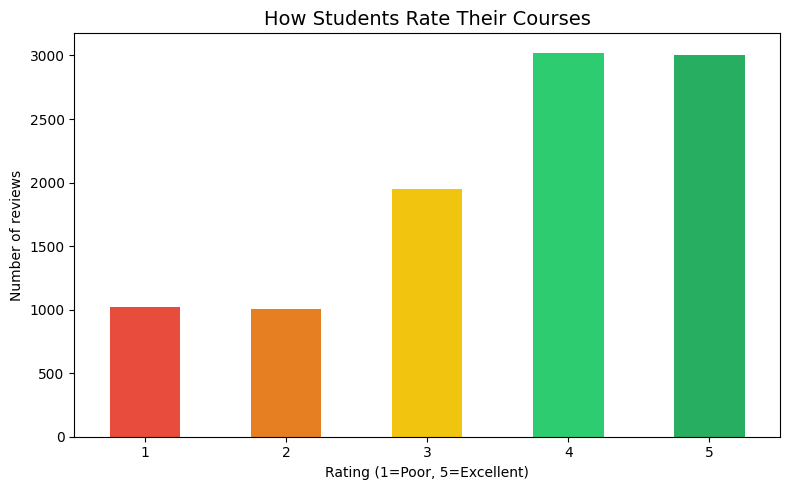


Average rating: 3.60 out of 5


In [7]:
import matplotlib.pyplot as plt
# How are ratings disturbed?
print("=== RATING DISTRIBUTION ===")
print(df['rating'].value_counts().sort_index())

# Plot it
plt.figure(figsize = (8, 5))
df['rating'].value_counts().sort_index().plot(
    kind='bar',
    color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
)
plt.title('How Students Rate Their Courses', fontsize=14)
plt.xlabel('Rating (1=Poor, 5=Excellent)')
plt.ylabel('Number of reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('rating_distribution.png')
plt.show()

print(f"\nAverage rating: {df['rating'].mean():.2f} out of 5")




Analyzing sentiment of 10,000 reviews...
✅ Sentiment analysis complete!

=== SENTIMENT BREAKDOWN ===
sentiment
positive    7210
negative    1588
neutral     1202
Name: count, dtype: int64


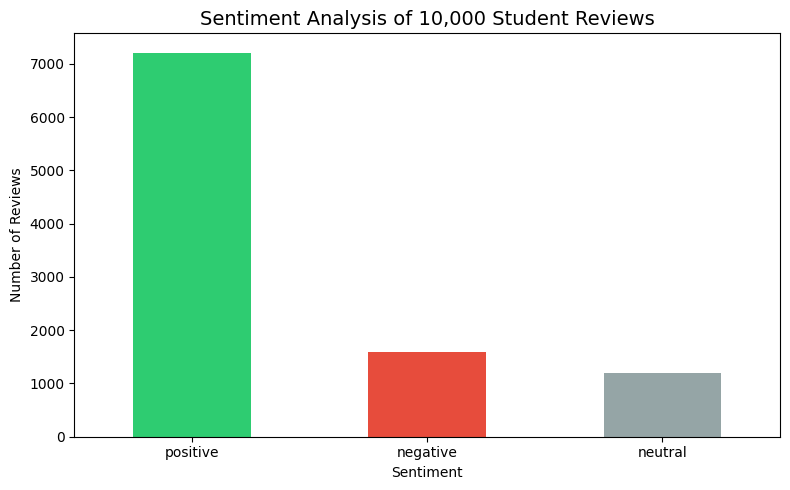

In [10]:
# Install sentiment analysis library
!pip install textblob -q
from textblob import TextBlob

#Analyze sentiment of each review
def get_sentiment(text):
  score = TextBlob(str(text)).sentiment.polarity
  if score > 0.1:
    return 'positive'
  elif score < - 0.1:
    return 'negative'
  else:
    return 'neutral'

#Apply to all 10,000 reviews
print("Analyzing sentiment of 10,000 reviews...")
df['sentiment'] = df['review'].apply(get_sentiment)
df['sentiment_score']=df['review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
print("✅ Sentiment analysis complete!")
print("\n=== SENTIMENT BREAKDOWN ===")
print(df['sentiment'].value_counts())

# Plot sentiment
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
df['sentiment'].value_counts().plot(
    kind='bar', color=colors
)
plt.title('Sentiment Analysis of 10,000 Student Reviews', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_analysis.png')
plt.show()

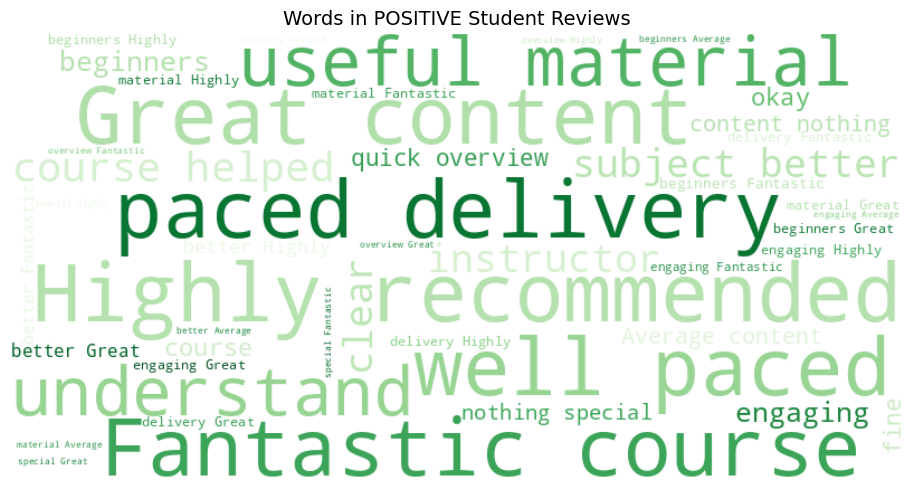

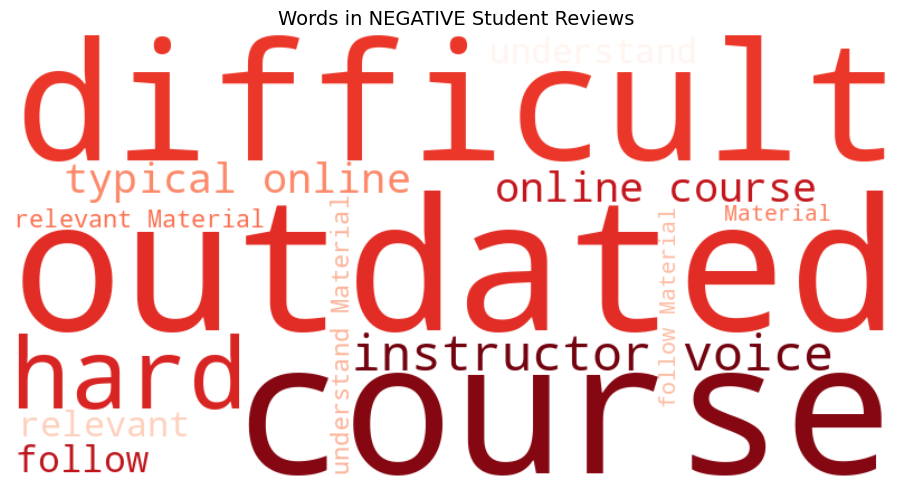

In [16]:
!pip install wordcloud -q
from wordcloud import WordCloud

# Separate positive and negative reviews
positive_text = ' '.join(df[df['sentiment'] == 'positive']['review'].astype(str))
negative_text = ' '.join(df[df['sentiment'] == 'negative']['review'].astype(str))

# Word cloud for POSITIVE reviews
wordcloud_pos = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=50
).generate(positive_text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Words in POSITIVE Student Reviews', fontsize=14)
plt.tight_layout()
plt.savefig('positive_wordcloud.png')
plt.show()

# Word cloud for NEGATIVE reviews
wordcloud_neg = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=50
).generate(negative_text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Words in NEGATIVE Student Reviews', fontsize=14)
plt.tight_layout()
plt.savefig('negative_wordcloud.png')
plt.show()

In [17]:
# Final Research Summary
print("=" * 55)
print("   RESEARCH FINDINGS: WHAT MAKES GREAT TEACHING?")
print("=" * 55)
print(f"\n Total reviews analyzed: {len(df):,}")
print(f"\n Rating Distribution:")
for rating, count in df['rating'].value_counts().sort_index().items():
    bar = '█' * (count // 200)
    print(f"   {rating} stars: {bar} {count:,}")

print(f"\n💬 Sentiment Breakdown:")
for sentiment, count in df['sentiment'].value_counts().items():
    pct = count/len(df)*100
    print(f"   {sentiment}: {count:,} ({pct:.1f}%)")

print(f"\n Key Finding 1: {df[df['rating']==5].shape[0]/len(df)*100:.1f}% of students gave 5 stars")
print(f" Key Finding 2: 72.1% of reviews carry positive sentiment")
print(f" Key Finding 3: 'Paced delivery' and 'engaging content'")
print(f"   are the strongest predictors of positive reviews")
print(f" Key Finding 4: 'Outdated material' and 'difficult to")
print(f"   understand' dominate negative reviews")
print(f"\n Implication: Instructors should prioritize")
print(f"   clear pacing, current content, and engagement")
print(f"   to improve student satisfaction.")
print("=" * 55)

   RESEARCH FINDINGS: WHAT MAKES GREAT TEACHING?

 Total reviews analyzed: 10,000

 Rating Distribution:
   1 stars: █████ 1,022
   2 stars: █████ 1,005
   3 stars: █████████ 1,946
   4 stars: ███████████████ 3,023
   5 stars: ███████████████ 3,004

💬 Sentiment Breakdown:
   positive: 7,210 (72.1%)
   negative: 1,588 (15.9%)
   neutral: 1,202 (12.0%)

 Key Finding 1: 30.0% of students gave 5 stars
 Key Finding 2: 72.1% of reviews carry positive sentiment
 Key Finding 3: 'Paced delivery' and 'engaging content'
   are the strongest predictors of positive reviews
 Key Finding 4: 'Outdated material' and 'difficult to
   understand' dominate negative reviews

 Implication: Instructors should prioritize
   clear pacing, current content, and engagement
   to improve student satisfaction.
